# Influence Functions: Where Does the Hessian Come From?

A short derivation of the Koh & Liang (2017) influence function. We'll then verify the formula numerically on a small MLP.

## What we'd like to know

A model is trained by minimising the empirical risk:

$$\hat\theta \;=\; \arg\min_{\theta} \; \frac{1}{n}\sum_{i=1}^{n} L(z_i, \theta).$$

We want to know: **how does each training point $z$ affect the model's loss on a particular test point $z_{\text{test}}$?**

The cleanest way to formalise this is to imagine smoothly upweighting $z$ by a small amount $\varepsilon$:

$$\hat\theta_{\varepsilon, z} \;=\; \arg\min_{\theta} \; \frac{1}{n}\sum_{i=1}^{n} L(z_i, \theta) \;+\; \varepsilon \, L(z, \theta).$$

When $\varepsilon = 0$ we recover the original $\hat\theta$. As $\varepsilon$ grows, $z$'s loss matters more, and the optimum drifts.

The quantity we actually want is:

$$\mathcal{I}(z, z_{\text{test}}) \;\equiv\; \frac{d \, L(z_{\text{test}}, \hat\theta_{\varepsilon, z})}{d\varepsilon}\bigg|_{\varepsilon = 0}$$

A positive value means upweighting $z$ would *increase* the test loss (it's hurting us); a negative value means it's helping.

## Step 1: chain rule

The test loss $L(z_{\text{test}}, \cdot)$ has no idea what $\varepsilon$ is. It only depends on $\varepsilon$ through the parameters that come out of training. So by the chain rule:

$$\frac{d \, L(z_{\text{test}}, \hat\theta_{\varepsilon, z})}{d\varepsilon}\bigg|_{0}
\;=\; \underbrace{\nabla_\theta L(z_{\text{test}}, \hat\theta)^{\top}}_{\text{easy: just a gradient}}
\;\cdot\; \underbrace{\frac{d\hat\theta_{\varepsilon, z}}{d\varepsilon}\bigg|_{0}}_{\text{the hard piece}}$$

The first factor is a single backward pass through the model at the trained parameters. The second factor is the troublesome one: it asks how the *learned parameters* shift when we perturb the loss.

That's hard because $\hat\theta_{\varepsilon, z}$ is defined as an *argmin*. There's no closed form. We can't just differentiate it directly.

## Step 2: differentiating through an argmin

Even though we can't write $\hat\theta_{\varepsilon, z}$ in closed form, we know one thing about it: it's a stationary point. The gradient of the perturbed objective vanishes there:

$$\frac{1}{n}\sum_i \nabla_\theta L(z_i, \hat\theta_{\varepsilon, z}) \;+\; \varepsilon \, \nabla_\theta L(z, \hat\theta_{\varepsilon, z}) \;=\; 0.$$

This is an *implicit* definition of $\hat\theta_{\varepsilon, z}$. The trick — the implicit function theorem — is to differentiate this whole equation with respect to $\varepsilon$, and then solve for $d\hat\theta / d\varepsilon$.

Differentiating w.r.t. $\varepsilon$ at $\varepsilon = 0$ (where $\hat\theta_{\varepsilon, z}$ becomes $\hat\theta$):

$$\underbrace{\left[\frac{1}{n}\sum_i \nabla^2_\theta L(z_i, \hat\theta)\right]}_{\displaystyle H_{\hat\theta}\;\text{appears here}} \cdot \frac{d\hat\theta_{\varepsilon, z}}{d\varepsilon}\bigg|_{0} \;+\; \nabla_\theta L(z, \hat\theta) \;=\; 0.$$

The Hessian shows up as the Jacobian of "take the gradient at $\hat\theta_{\varepsilon, z}$" with respect to $\hat\theta_{\varepsilon, z}$ itself — that's just the second derivative of the loss. **It's not chosen; it falls out of the chain rule applied to a vanishing-gradient condition.**

Solving for the missing piece:

$$\frac{d\hat\theta_{\varepsilon, z}}{d\varepsilon}\bigg|_{0} \;=\; -\, H_{\hat\theta}^{-1} \, \nabla_\theta L(z, \hat\theta).$$

## Step 3: assemble

Plug back into the chain rule from Step 1:

$$\boxed{\;\;\mathcal{I}(z, z_{\text{test}}) \;=\; -\, \nabla_\theta L(z_{\text{test}}, \hat\theta)^{\top} \, H_{\hat\theta}^{-1} \, \nabla_\theta L(z, \hat\theta)\;\;}$$

This is the Koh & Liang influence function. Reading it left-to-right:

1. $\nabla_\theta L(z, \hat\theta)$ — the "force" that upweighting $z$ would exert on the loss landscape.
2. $H_{\hat\theta}^{-1}$ — the *compliance* of the optimum: a Newton step that converts force into displacement. Sharp curvature ⇒ $\hat\theta$ barely moves; flat curvature ⇒ it slides far.
3. $\nabla_\theta L(z_{\text{test}}, \hat\theta)$ — the direction in parameter space the test loss is sensitive to.

The full expression dot-products them together: *how much does the perturbation push $\hat\theta$ in a direction the test loss cares about?*

## Connection to leave-one-out

Removing point $z$ from the training set is the same as setting its weight to $0$ instead of $1/n$ — i.e., upweighting by $\varepsilon = -1/n$. So a first-order Taylor expansion gives:

$$L(z_{\text{test}}, \hat\theta_{-z}) \;-\; L(z_{\text{test}}, \hat\theta) \;\approx\; -\frac{1}{n}\, \mathcal{I}(z, z_{\text{test}}).$$

This is what we'll verify numerically below: predicted change vs. actual change after literally retraining without each point.

## A small worked example

Let's verify the formula on a tiny MLP. We'll:

1. Train a 2-layer MLP on a 2D synthetic classification problem.
2. Compute the influence of each training point on the loss at a single test point, using the formula above.
3. For comparison, retrain the model $n$ times leaving each point out, and measure the *actual* test-loss change.

If the derivation is right, the predicted and actual changes should fall on the line $y = x$.

We use L2 regularisation to keep the loss strongly convex enough that $H_{\hat\theta}$ is well-conditioned and the local linearisation holds.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# Synthetic 2D binary classification: a noisy ring boundary
n = 60
X = torch.randn(n, 2)
y = ((X[:, 0] ** 2 + X[:, 1] ** 2) > 1.5).float().unsqueeze(1)

X_test = torch.randn(20, 2)
y_test = ((X_test[:, 0] ** 2 + X_test[:, 1] ** 2) > 1.5).float().unsqueeze(1)

print(f"Training set: {n} points, {int(y.sum())} positives")

Training set: 60 points, 26 positives


In [2]:
# A tiny MLP: 2 -> 8 -> 1
def make_model():
    torch.manual_seed(42)
    return nn.Sequential(
        nn.Linear(2, 8), nn.Tanh(),
        nn.Linear(8, 1),
    )

LAMBDA = 0.02     # L2 strength: keeps the loss strongly convex
bce = nn.BCEWithLogitsLoss(reduction="mean")

def total_loss(model, X_, y_, weights=None):
    # Mean BCE + L2.  `weights` lets us re-weight individual examples.
    logits = model(X_)
    if weights is None:
        loss = bce(logits, y_)
    else:
        per_ex = nn.functional.binary_cross_entropy_with_logits(
            logits, y_, reduction="none"
        ).squeeze()
        loss = (weights * per_ex).sum() / weights.sum()
    l2 = sum((p ** 2).sum() for p in model.parameters())
    return loss + LAMBDA * l2

def train(model, X_, y_, weights=None):
    # Train to (near) optimum with L-BFGS -- we want a true argmin.
    opt = torch.optim.LBFGS(
        model.parameters(), lr=0.1, max_iter=2000,
        tolerance_grad=1e-9, tolerance_change=1e-12,
        line_search_fn="strong_wolfe",
    )
    def closure():
        opt.zero_grad()
        loss = total_loss(model, X_, y_, weights)
        loss.backward()
        return loss
    opt.step(closure)
    return model

model = make_model()
train(model, X, y)
params = list(model.parameters())
n_params = sum(p.numel() for p in params)
print(f"Trained. {n_params} parameters total.")

Trained. 33 parameters total.


### Computing $H_{\hat\theta}^{-1}$

For a model this small we can afford the full Hessian. We get it row-by-row by differentiating each entry of the gradient vector.

(For real-world models with millions of parameters this is intractable; you'd use stochastic estimators like LiSSA or conjugate gradients — but the formula being computed is the same.)

In [3]:
def flat_grad(loss, params, create_graph=False):
    grads = torch.autograd.grad(loss, params, create_graph=create_graph)
    return torch.cat([g.reshape(-1) for g in grads])

# Hessian of the empirical loss at theta_hat
L_train = total_loss(model, X, y)
g_train = flat_grad(L_train, params, create_graph=True)

H = torch.zeros(n_params, n_params)
for i in range(n_params):
    H_row = torch.autograd.grad(g_train[i], params, retain_graph=True)
    H[i] = torch.cat([h.reshape(-1) for h in H_row])

H = 0.5 * (H + H.T)                                          # symmetrise
H_inv = torch.linalg.inv(H + 1e-4 * torch.eye(n_params))     # tiny damping
print(f"Hessian shape: {tuple(H.shape)}, cond(H) approx {torch.linalg.cond(H).item():.1f}")

Hessian shape: (33, 33), cond(H) approx 159.8


### Influence of every training point on one test point

In [4]:
# Pick a test point and get its gradient
test_idx = 0
x_te = X_test[test_idx:test_idx + 1]
y_te = y_test[test_idx:test_idx + 1]

g_test = flat_grad(bce(model(x_te), y_te), params).detach()

# Influence of each training point: I(z_i, z_test) = -g_test^T H^-1 g_i
predicted_influence = np.zeros(n)
for i in range(n):
    g_i = flat_grad(bce(model(X[i:i+1]), y[i:i+1]), params).detach()
    predicted_influence[i] = -(g_test @ H_inv @ g_i).item()

# Predicted change in test loss when removing point i: -I/n
predicted_change = -predicted_influence / n

### Ground truth: actually retrain $n$ times

For each training point $i$, we retrain from scratch with that point removed, then measure how much the test loss actually changed.

In [5]:
L_test_base = bce(model(x_te), y_te).item()

actual_change = np.zeros(n)
for i in range(n):
    mask = torch.ones(n)
    mask[i] = 0.0
    m_i = make_model()
    train(m_i, X, y, weights=mask)
    actual_change[i] = bce(m_i(x_te), y_te).item() - L_test_base

corr = np.corrcoef(predicted_change, actual_change)[0, 1]
print(f"Pearson correlation: {corr:.3f}")

Pearson correlation: 0.998


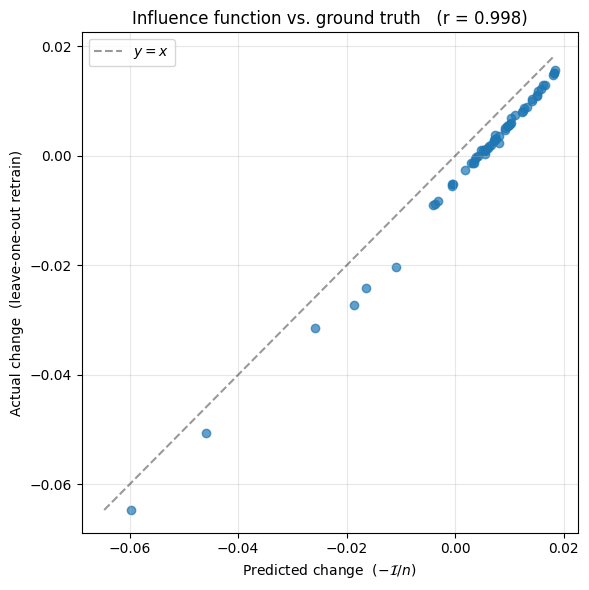

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(predicted_change, actual_change, alpha=0.7)

lo = min(predicted_change.min(), actual_change.min())
hi = max(predicted_change.max(), actual_change.max())
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4, label="$y = x$")

ax.set_xlabel(r"Predicted change  ($-\mathcal{I}/n$)")
ax.set_ylabel("Actual change  (leave-one-out retrain)")
ax.set_title(f"Influence function vs. ground truth   (r = {corr:.3f})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## What this tells us

The influence-function prediction tracks the actual leave-one-out change very closely — points sit near $y = x$. Some points have positive influence (their removal *increased* the test loss; they were helping) and some have negative influence (they were hurting). The formula correctly identifies both, *without ever retraining the model*. The single Hessian inverse encodes everything we need to estimate the effect of removing any of the $n$ training points.

A few things worth noting about why this works (and when it doesn't):

**Strong convexity matters.** We added L2 regularisation to make the loss strongly convex around $\hat\theta$. Without it, the Hessian can be singular or near-singular, and $H^{-1}$ blows up. In practice people add a damping term $H + \lambda I$ when applying this to non-convex models like deep neural networks.

**The approximation is local.** The derivation is a first-order Taylor expansion around $\hat\theta$. If a single training point has a large effect — enough to move $\hat\theta$ far — the linearisation breaks down. Outliers and high-influence points are exactly where the formula is least trustworthy.

**Scaling up.** For real networks the full Hessian has $p^2$ entries with $p$ in the millions. Two main strategies:
- *Hessian-vector products via LiSSA or conjugate gradients.* You never form $H$ explicitly, just compute $H v$ for vectors $v$, which costs one extra backward pass.
- *Approximations to $H$.* Gauss-Newton, empirical Fisher, or block-diagonal versions trade exactness for tractability.

**The takeaway.** The Hessian appears in the influence function for one reason: $\hat\theta$ is an argmin, and the only way to differentiate through an argmin is via its first-order condition — and differentiating a gradient gives you a Hessian. Everything else is just chain rule.